In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from collections import Counter
import string
from tqdm import tqdm
from wordcloud import WordCloud, STOPWORDS

**Import Dataset**

In [2]:
train_df=pd.read_csv('../input/commonlitreadabilityprize/train.csv')
test_df=pd.read_csv('../input/commonlitreadabilityprize/test.csv')
sample_sub=pd.read_csv('../input/commonlitreadabilityprize/sample_submission.csv')

In [3]:
print('Train data Shape: ',train_df.shape)
train_df.head(10)

Train data Shape:  (2834, 6)


,id,url_legal,license,excerpt,target,standard_error
0,c12129c31,NaN,NaN,When the young people returned to the ballroom...,-0.340259,0.464009
1,85aa80a4c,NaN,NaN,"All through dinner time, Mrs. Fayre was somewh...",-0.315372,0.480805
2,b69ac6792,NaN,NaN,"As Roger had predicted, the snow departed as q...",-0.580118,0.476676
3,dd1000b26,NaN,NaN,And outside before the palace a great garden w...,-1.054013,0.450007
4,37c1b32fb,NaN,NaN,Once upon a time there were Three Bears who li...,0.247197,0.510845
5,f9bf357fe,NaN,NaN,Hal and Chester found ample time to take an in...,-0.861809,0.480936
6,eaf8e7355,NaN,NaN,Hal Paine and Chester Crawford were typical Am...,-1.759061,0.476507
7,0a43a07f1,NaN,NaN,"On the twenty-second of February, 1916, an aut...",-0.952325,0.498116
8,f7eff7419,NaN,NaN,The boys left the capitol and made their way d...,-0.371641,0.463710
9,d96e6dbcd,NaN,NaN,One day he had gone beyond any point which he ...,-1.238432,0.465900


In [4]:
imp_cols=['excerpt','target']
train_df=train_df[imp_cols]
train_df.head()

,excerpt,target
0,When the young people returned to the ballroom...,-0.340259
1,"All through dinner time, Mrs. Fayre was somewh...",-0.315372
2,"As Roger had predicted, the snow departed as q...",-0.580118
3,And outside before the palace a great garden w...,-1.054013
4,Once upon a time there were Three Bears who li...,0.247197


**Target Distribution Plot**

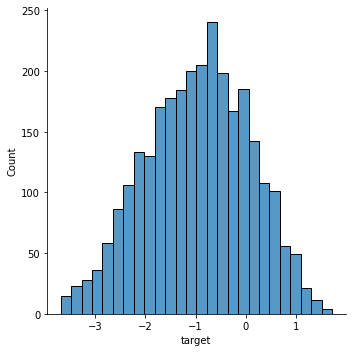

In [5]:
sns.displot(train_df['target'])

In [6]:
train_df['target'].describe()

count    2834.000000
mean       -0.959319
std         1.033579
min        -3.676268
25%        -1.690320
50%        -0.912190
75%        -0.202540
max         1.711390
Name: target, dtype: float64

**Sentences length Distribution**

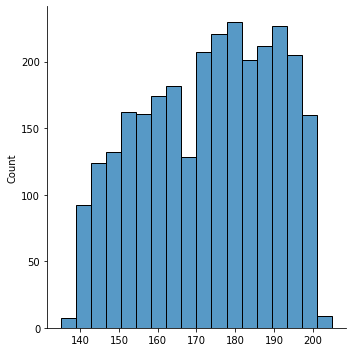

In [7]:
#Lets take a look at length of sentences
sent_len=[len(i.split()) for i in train_df['excerpt']]
sns.displot(sent_len)

**Clean sentences**
* Remove puntuations
* Remove stop words
* Remove numbers and words containing numbers

In [8]:
#Now let's clean the paragraphs for better understanding of words and length
sp=stopwords.words('english')
#Remove punctuation
print('Cleaning Punctuations')
cleaned_text=[txt.translate(str.maketrans('','',string.punctuation)) for txt in train_df['excerpt']]

print('Cleaning numbers')
cleaned_text=[' '.join([i for i in txt.lower().split() if i.isalpha()]) for txt in cleaned_text]

print('Cleaning Stopwords')
cleaned_text=[' '.join(i for i in txt.split() if i not in sp) for txt in cleaned_text]


Cleaning Punctuations
Cleaning numbers
Cleaning Stopwords


**Length distribution of sentences after cleaning**

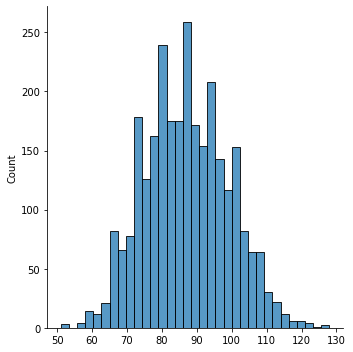

In [9]:
#Let's take a look at how cleaning affected each sentence
sent_len=[len(i.split(),) for i in cleaned_text]
sns.displot(sent_len)

**Get frequency of each word in corpus**


In [10]:
#Counter rare words
corpus=' '.join([i for i in cleaned_text])
word_freq=Counter(corpus.split())

#Words with freq less than 10
frequent_words=[]
for word in tqdm(word_freq.keys()):
    if word_freq[word]<=10:
        frequent_words.append(word)

frequent_words=' '.join([i for i in frequent_words])

100%|██████████| 28260/28260 [00:00<00:00, 926443.47it/s]


**Word Cloud of most rare words**

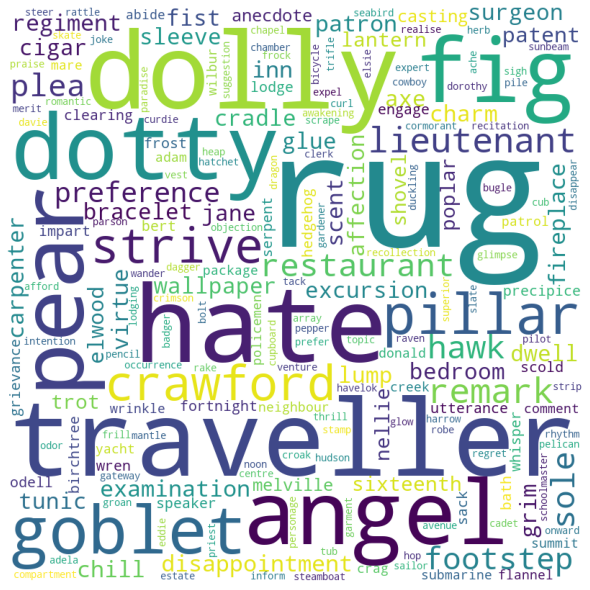

In [11]:
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                min_font_size = 10).generate(frequent_words)

plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()